In [ ]:
# Import required libraries
import pandas as pd
import os
from scipy import stats
from scipy.stats import wilcoxon
import numpy as np
import statsmodels.formula.api as smf
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from scipy.stats import ttest_1samp
from datetime import datetime
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Read road terminations
data_folder = "/content/drive/Shareddrives/OSM-ODECO/HOTOSM/inconsistency/continuation/"
inputfile = os.path.join(data_folder, "continuation.csv")
df = pd.read_csv(inputfile)
df["area"]=df["area_of_shrunk_grids"]+df["area_of_border_buffer"]
df["nodes"]=df["nodes_in_shrunk_grids"]+df["nodes_in_border_buffer"]
df

,project_id,grid_type,shrink_distance,shrink_type,nodes_in_shrunk_grids,nodes_in_border_buffer,area_of_shrunk_grids,area_of_border_buffer,nodes_per_area_shrunk_grids,nodes_per_area_border_buffer,area,nodes
0,105,MOCKUP,5,percentage,857,44,4.304850e+07,2.231740e+06,0.000020,0.000020,4.528024e+07,901
1,105,MOCKUP,10,percentage,824,77,4.078661e+07,4.493630e+06,0.000020,0.000017,4.528024e+07,901
2,105,MOCKUP,15,percentage,778,123,3.852519e+07,6.755050e+06,0.000020,0.000018,4.528024e+07,901
3,105,ORIGINAL,5,percentage,849,52,4.301865e+07,2.261588e+06,0.000020,0.000023,4.528024e+07,901
4,105,ORIGINAL,10,percentage,795,106,4.075624e+07,4.523996e+06,0.000020,0.000023,4.528024e+07,901
...,...,...,...,...,...,...,...,...,...,...,...,...
12421,17269,MOCKUP,10,percentage,10,0,1.463051e+06,1.611823e+05,0.000007,0.000000,1.624234e+06,10
12422,17269,MOCKUP,15,percentage,10,0,1.381827e+06,2.424068e+05,0.000007,0.000000,1.624234e+06,10
12423,17269,ORIGINAL,5,percentage,10,0,1.543071e+06,8.116311e+04,0.000006,0.000000,1.624234e+06,10
12424,17269,ORIGINAL,10,percentage,9,1,1.461970e+06,1.622637e+05,0.000006,0.000006,1.624234e+06,10


In [ ]:
# Projects with positive count
dfkw=df[df["nodes"]>0]
dfkw["nodes_per_buffer"]=dfkw["nodes_in_border_buffer"]/dfkw["nodes"]*100
dfkw["area_in_border_per"]=dfkw["area_of_border_buffer"]/dfkw["area"]*100
dfkw["nodes_per_buffer"]=dfkw["nodes_per_buffer"]*dfkw["shrink_distance"]/dfkw["area_in_border_per"]

<ipython-input-39-24c45b243cfc>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfkw["nodes_per_buffer"]=dfkw["nodes_in_border_buffer"]/dfkw["nodes"]*100
<ipython-input-39-24c45b243cfc>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfkw["area_in_border_per"]=dfkw["area_of_border_buffer"]/dfkw["area"]*100
<ipython-input-39-24c45b243cfc>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in

# Characterization of area models around the edge (5%, 10%, 15%)

In [ ]:
# Describe nodes around the edge with 5%
dfkw['nodes_per_buffer'][dfkw["grid_type"]=="ORIGINAL"][dfkw["shrink_distance"]==5].describe()

,nodes_per_buffer
count,2021.000000
mean,9.986193
std,6.118398
min,0.000000
25%,6.106350
50%,8.618539
75%,12.550402
max,63.309888


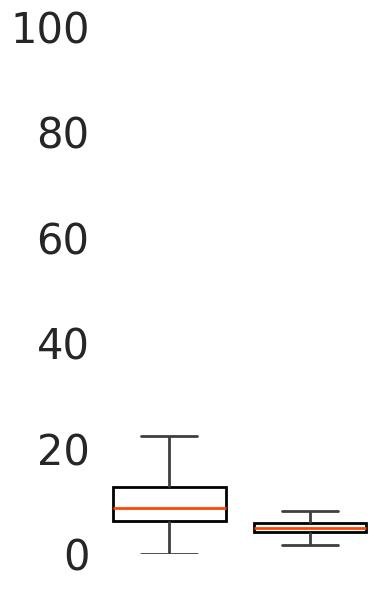

In [ ]:
# Filter the data where shrink_distance == 5
filtered_df = dfkw[dfkw["shrink_distance"]==5][["grid_type","nodes_per_buffer"]]

# Get the reversed order of grid types
unique_types = filtered_df["grid_type"].unique()
reversed_order = list(reversed(unique_types))

# Set up the figure
plt.figure(figsize=(4, 6))
sns.set_style("white")

# Create the boxplot
ax = sns.boxplot(
    x="grid_type",
    y="nodes_per_buffer",
    data=filtered_df,
    order=reversed_order,
    width=0.8,
    linewidth=2,
    showfliers=False,
    boxprops=dict(edgecolor="black", facecolor="white"),
    medianprops=dict(color="#FF4500", linewidth=2)
)

# Set vertical axis limits
ax.set_ylim(0, 100)

# Remove background and X axis elements
sns.despine(left=True, bottom=True)
ax.set(xlabel=None, ylabel=None)
ax.set_xticks([])  # Remove x-axis ticks
ax.tick_params(axis='y', labelsize=30)  # Show y-axis ticks

# Final layout adjustments
plt.tight_layout()
plt.show()

In [ ]:
# Filter the data
filtered = dfkw.loc[(dfkw["grid_type"] == "ORIGINAL") & (dfkw["shrink_distance"] == 5), "nodes_per_buffer"]

# Perform one-sample t-test against population mean = 15
t_test_result = ttest_1samp(filtered, popmean=5)

# Print result
print(t_test_result)

TtestResult(statistic=np.float64(36.636547032343536), pvalue=np.float64(9.091162439930633e-226), df=np.int64(2020))


In [ ]:
#Describe nodes around the edge with 10%
dfkw['nodes_per_buffer'][dfkw["grid_type"]=="ORIGINAL"][dfkw["shrink_distance"]==10].describe()

,nodes_per_buffer
count,2021.000000
mean,16.233433
std,7.760282
min,0.000000
25%,11.538744
50%,14.828000
75%,19.570586
max,99.784461


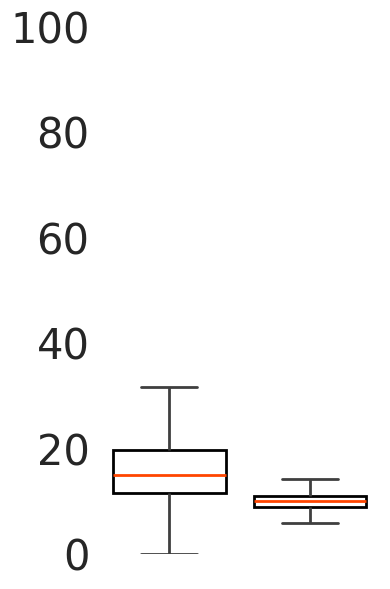

In [ ]:
# Filter the data where shrink_distance == 10
filtered_df = dfkw[dfkw["shrink_distance"]==10][["grid_type","nodes_per_buffer"]]

# Get the reversed order of grid types
unique_types = filtered_df["grid_type"].unique()
reversed_order = list(reversed(unique_types))

# Set up the figure
plt.figure(figsize=(4, 6))
sns.set_style("white")

# Create the boxplot
ax = sns.boxplot(
    x="grid_type",
    y="nodes_per_buffer",
    data=filtered_df,
    order=reversed_order,
    width=0.8,
    linewidth=2,
    showfliers=False,
    boxprops=dict(edgecolor="black", facecolor="white"),
    medianprops=dict(color="#FF4500", linewidth=2)
)

# Set vertical axis limits
ax.set_ylim(0, 100)

# Remove background and X axis elements
sns.despine(left=True, bottom=True)
ax.set(xlabel=None, ylabel=None)
ax.set_xticks([])  # Remove x-axis ticks
ax.tick_params(axis='y', labelsize=30)  # Show y-axis ticks

# Final layout adjustments
plt.tight_layout()
plt.show()

In [ ]:
# Filter the data
filtered = dfkw.loc[(dfkw["grid_type"] == "ORIGINAL") & (dfkw["shrink_distance"] == 10), "nodes_per_buffer"]

# Perform one-sample t-test against population mean = 15
t_test_result = ttest_1samp(filtered, popmean=10)

# Print result
print(t_test_result)

TtestResult(statistic=np.float64(36.110457833017485), pvalue=np.float64(9.636704384833063e-221), df=np.int64(2020))


In [ ]:
#Describe nodes around the edge with 15%
dfkw['nodes_per_buffer'][dfkw["grid_type"]=="ORIGINAL"][dfkw["shrink_distance"]==15].describe()

,nodes_per_buffer
count,2021.000000
mean,21.655959
std,8.764022
min,0.000000
25%,16.594170
50%,20.120378
75%,25.283693
max,99.988757


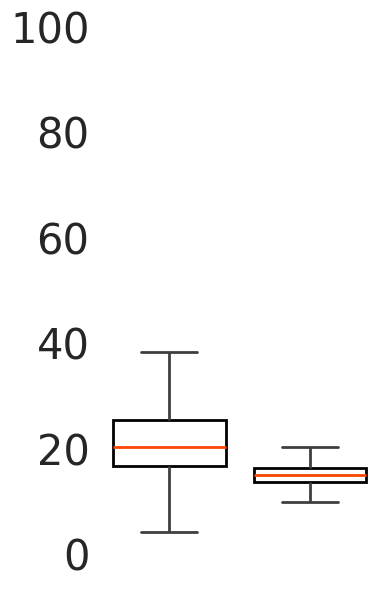

In [ ]:
# Filter the data where shrink_distance == 15
filtered_df = dfkw[dfkw["shrink_distance"]==15][["grid_type","nodes_per_buffer"]]

# Get the reversed order of grid types
unique_types = filtered_df["grid_type"].unique()
reversed_order = list(reversed(unique_types))

# Set up the figure
plt.figure(figsize=(4, 6))
sns.set_style("white")

# Create the boxplot
ax = sns.boxplot(
    x="grid_type",
    y="nodes_per_buffer",
    data=filtered_df,
    order=reversed_order,
    width=0.8,
    linewidth=2,
    showfliers=False,
    boxprops=dict(edgecolor="black", facecolor="white"),
    medianprops=dict(color="#FF4500", linewidth=2)
)

# Set vertical axis limits
ax.set_ylim(0, 100)

# Remove background and X axis elements
sns.despine(left=True, bottom=True)
ax.set(xlabel=None, ylabel=None)
ax.set_xticks([])  # Remove x-axis ticks
ax.tick_params(axis='y', labelsize=30)  # Show y-axis ticks

# Final layout adjustments
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import ttest_1samp

# Filter the data
filtered = dfkw.loc[(dfkw["grid_type"] == "ORIGINAL") & (dfkw["shrink_distance"] == 15), "nodes_per_buffer"]

# Perform one-sample t-test against population mean = 15
t_test_result = ttest_1samp(filtered, popmean=15)

# Print result
print(t_test_result)

TtestResult(statistic=np.float64(34.14210982024037), pvalue=np.float64(4.338688787207277e-202), df=np.int64(2020))


# Characterization of random area models (5%, 10%, 15%)


In [ ]:
#Describe random nodes with 5%
dfkw['nodes_per_buffer'][dfkw["grid_type"]=="MOCKUP"][dfkw["shrink_distance"]==5].describe()

,nodes_per_buffer
count,2021.000000
mean,4.970324
std,2.533121
min,0.000000
25%,4.052473
50%,4.923675
75%,5.683113
max,50.873898


In [ ]:
from scipy.stats import ttest_1samp

# Filter the data
filtered = dfkw.loc[(dfkw["grid_type"] == "MOCKUP") & (dfkw["shrink_distance"] == 5), "nodes_per_buffer"]

# Perform one-sample t-test against population mean = 15
t_test_result = ttest_1samp(filtered, popmean=5)

# Print result
print(t_test_result)

TtestResult(statistic=np.float64(-0.5266620733531922), pvalue=np.float64(0.5984861023870051), df=np.int64(2020))


In [ ]:
#Describe random nodes with 10%
dfkw['nodes_per_buffer'][dfkw["grid_type"]=="MOCKUP"][dfkw["shrink_distance"]==10].describe()

,nodes_per_buffer
count,2021.000000
mean,9.971108
std,3.293268
min,0.000000
25%,8.876476
50%,9.944749
75%,10.951490
max,50.372618


In [ ]:
from scipy.stats import ttest_1samp

# Filter the data
filtered = dfkw.loc[(dfkw["grid_type"] == "MOCKUP") & (dfkw["shrink_distance"] == 10), "nodes_per_buffer"]

# Perform one-sample t-test against population mean = 15
t_test_result = ttest_1samp(filtered, popmean=10)

# Print result
print(t_test_result)

TtestResult(statistic=np.float64(-0.3944025332776912), pvalue=np.float64(0.693325507941392), df=np.int64(2020))


In [ ]:
#Describe random nodes with 15%
dfkw['nodes_per_buffer'][dfkw["grid_type"]=="MOCKUP"][dfkw["shrink_distance"]==15].describe()

,nodes_per_buffer
count,2021.000000
mean,15.017506
std,4.647071
min,0.000000
25%,13.559662
50%,14.927078
75%,16.223221
max,99.997119


In [ ]:
from scipy.stats import ttest_1samp

# Filter the data
filtered = dfkw.loc[(dfkw["grid_type"] == "MOCKUP") & (dfkw["shrink_distance"] == 15), "nodes_per_buffer"]

# Perform one-sample t-test against population mean = 15
t_test_result = ttest_1samp(filtered, popmean=15)

# Print result
print(t_test_result)

TtestResult(statistic=np.float64(0.16935592671077174), pvalue=np.float64(0.8655336452870908), df=np.int64(2020))


# Profiling the difference between the observed and expected proportion of nodes ('Difference') and its rate of change ('Change') as a function of edge area at 5% increments


In [ ]:
# Read road termination data for multiple area configurations
data_folder = "/content/drive/Shareddrives/OSM-ODECO/HOTOSM/inconsistency/continuation/"
inputfile = os.path.join(data_folder, "continuationtotal.csv")
curve = pd.read_csv(inputfile)
curve["area"]=curve["area_of_shrunk_grids"]+curve["area_of_border_buffer"]
curve["nodes"]=curve["nodes_in_shrunk_grids"]+curve["nodes_in_border_buffer"]
curve=curve[curve["nodes"]>0][curve["grid_type"]=="ORIGINAL"][curve["shrink_distance"]>15]
curve["nodes_per_buffer"]=curve["nodes_in_border_buffer"]/curve["nodes"]*100
curve["area_in_border_per"]=curve["area_of_border_buffer"]/curve["area"]*100
curve["nodes_per_buffer"]=curve["nodes_per_buffer"]*curve["shrink_distance"]/curve["area_in_border_per"]
curve.loc[curve["nodes_per_buffer"] > 100, "nodes_per_buffer"] = 100
curve = pd.concat([curve, dfkw[dfkw["nodes"]>0][dfkw["grid_type"]=="ORIGINAL"]] )
curve["diff"]=(curve["nodes_per_buffer"]-curve["shrink_distance"])
curve=curve[curve["shrink_distance"].isin([5,10,15,20,25,30,35,40,45,50,55,60,65,70,74,80,85,90,95,100])]
curve

<ipython-input-55-9abe2d2e5167>:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  curve=curve[curve["nodes"]>0][curve["grid_type"]=="ORIGINAL"][curve["shrink_distance"]>15]
<ipython-input-55-9abe2d2e5167>:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  curve=curve[curve["nodes"]>0][curve["grid_type"]=="ORIGINAL"][curve["shrink_distance"]>15]


,project_id,grid_type,shrink_distance,shrink_type,nodes_in_shrunk_grids,nodes_in_border_buffer,area_of_shrunk_grids,area_of_border_buffer,nodes_per_area_shrunk_grids,nodes_per_area_border_buffer,area,nodes,nodes_per_buffer,area_in_border_per,diff
22,105,ORIGINAL,20,percentage,680,221,3.616931e+07,9.110931e+06,0.000019,0.000024,4.528024e+07,901,24.380544,20.121209,4.380544
27,105,ORIGINAL,25,percentage,642,259,3.417413e+07,1.110610e+07,0.000019,0.000023,4.528024e+07,901,29.299616,24.527487,4.299616
32,105,ORIGINAL,30,percentage,592,309,3.167094e+07,1.360929e+07,0.000019,0.000023,4.528024e+07,901,34.231665,30.055705,4.231665
37,105,ORIGINAL,35,percentage,543,358,2.920610e+07,1.607414e+07,0.000019,0.000022,4.528024e+07,901,39.174842,35.499238,4.174842
42,105,ORIGINAL,40,percentage,501,400,2.716892e+07,1.811131e+07,0.000018,0.000022,4.528024e+07,901,44.397029,39.998277,4.397029
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12418,17265,ORIGINAL,10,percentage,340,43,1.362062e+07,1.513004e+06,0.000025,0.000028,1.513363e+07,383,11.229818,9.997628,1.229818
12419,17265,ORIGINAL,15,percentage,328,55,1.286426e+07,2.269364e+06,0.000025,0.000024,1.513363e+07,383,14.364615,14.995508,-0.635385
12423,17269,ORIGINAL,5,percentage,10,0,1.543071e+06,8.116311e+04,0.000006,0.000000,1.624234e+06,10,0.000000,4.997009,-5.000000
12424,17269,ORIGINAL,10,percentage,9,1,1.461970e+06,1.622637e+05,0.000006,0.000006,1.624234e+06,10,10.009839,9.990171,0.009839


In [ ]:
# Calculate mean and median difference between the observed and expected proportion of nodes at varying area configurations
curvetable=curve.groupby(curve.shrink_distance).agg({'diff': ['median',"mean"]})

flat_cols = []

# iterate through this tuples and
# join them as single string
for i in curvetable.columns:
    flat_cols.append(i[0]+'_'+i[1])

# now assign the list of flattened
# columns to the grouped columns.
curvetable.columns = flat_cols

curvetable

,diff_median,diff_mean
shrink_distance,,
5,3.618539,4.986193
10,4.828000,6.233433
15,5.120378,6.655959
20,5.271936,6.591512
25,5.376067,6.559348
30,5.183659,6.267137
35,4.941989,5.992886
40,4.867479,5.660722
45,4.589553,5.213935


In [ ]:
# Plot the difference between the observed and expected proportion of nodes ('Difference') and its rate of change ('Change') as a function of edge area at 5% increments
curvetable["change_median"]=curvetable["diff_median"]-curvetable["diff_median"].shift()
curvetable["change_mean"]=curvetable["diff_mean"]-curvetable["diff_mean"].shift()
curve.loc[curve["nodes_per_buffer"] > 100, "nodes_per_buffer"] = 100
curvetable.reset_index()
curvetable['change_median'] = curvetable['change_median'].fillna(3.618539)
curvetable['change_mean'] = curvetable['change_mean'].fillna(4.986193)
curvetable[["diff_mean","change_mean"]].plot()

<Axes: xlabel='shrink_distance'>

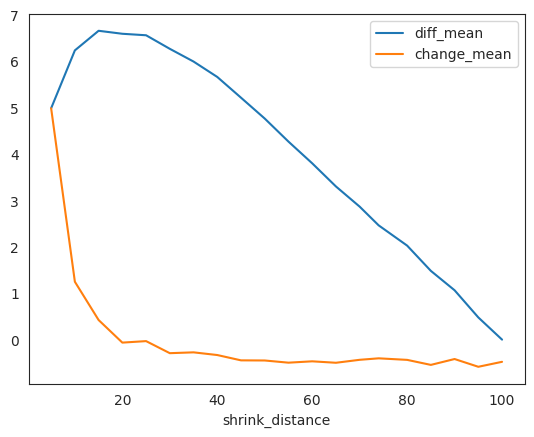

In [ ]:
border=[0.010102051443364402,
0.02303039929152717,
0.036319075225214825,
0.04999999999999999,
0.06411010564593267,
0.0786925113411821,
0.09379807976820198,
0.10948751620466729,
0.12583426132260583,
0.1429285785728575,
0.1608835008437366,
0.17984378812835755,
0.2,
0.2216117818584989,
0.24504902432036074,
0.27087121525220803,
0.3,
0.33416876048223,
0.377525512860841,
0.44999999999999996]
# Add border for plotting
curvetable['border']=border

,diff_median,diff_mean,change_median,change_mean,border
shrink_distance,,,,,
5,3.618539,4.986193,3.618539,4.986193,0.010102
10,4.828000,6.233433,1.209461,1.247241,0.023030
15,5.120378,6.655959,0.292377,0.422526,0.036319
20,5.271936,6.591512,0.151558,-0.064447,0.050000
25,5.376067,6.559348,0.104131,-0.032163,0.064110
30,5.183659,6.267137,-0.192408,-0.292211,0.078693
35,4.941989,5.992886,-0.241670,-0.274251,0.093798
40,4.867479,5.660722,-0.074510,-0.332164,0.109488
45,4.589553,5.213935,-0.277926,-0.446787,0.125834


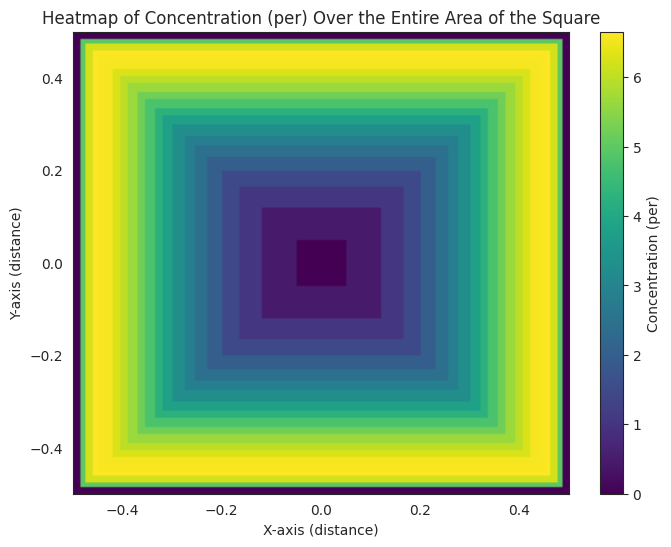

In [ ]:
# Plot the difference between the observed and expected proportion of nodes ('Difference') as a heatmap
# Assume 'data' is your DataFrame with columns 'd' and 'per'
d = curvetable['border']
per = curvetable['diff_mean']

# Create a grid representing the square area
square_size = 1  # Assume the square size is normalized to 1 for simplicity
grid_size = 200
x = np.linspace(-square_size/2, square_size/2, grid_size)
y = np.linspace(-square_size/2, square_size/2, grid_size)
X, Y = np.meshgrid(x, y)

# Define the area based on 'd' and assign 'per' values uniformly across each area
Z = np.zeros_like(X)

# Loop through each 'd' value and apply the corresponding 'per' across the area
for margin, concentration in zip(d, per):
    mask = (np.abs(X) <= square_size/2 - margin) & (np.abs(Y) <= square_size/2 - margin)
    Z[mask] = concentration

# Plot the heatmap
plt.figure(figsize=(8, 6))
plt.imshow(Z, extent=[-square_size/2, square_size/2, -square_size/2, square_size/2], origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(label='Concentration (per)')
plt.title('Heatmap of Concentration (per) Over the Entire Area of the Square')
plt.xlabel('X-axis (distance)')
plt.ylabel('Y-axis (distance)')
#plt.grid(True)
plt.show()

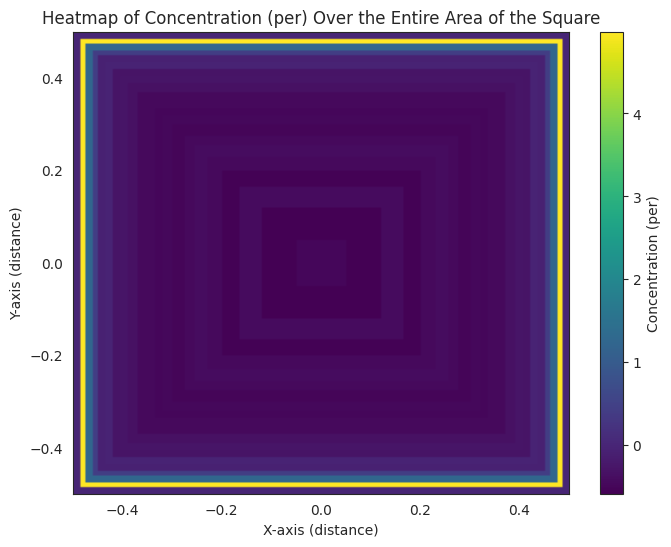

In [ ]:
# Plot the difference between the rate of change ('Change') as a heatmap
# Assume 'data' is your DataFrame with columns 'd' and 'per'
d = curvetable['border']
per = curvetable['change_mean']

# Create a grid representing the square area
square_size = 1  # Assume the square size is normalized to 1 for simplicity
grid_size = 200
x = np.linspace(-square_size/2, square_size/2, grid_size)
y = np.linspace(-square_size/2, square_size/2, grid_size)
X, Y = np.meshgrid(x, y)

# Define the area based on 'd' and assign 'per' values uniformly across each area
Z = np.zeros_like(X)

# Loop through each 'd' value and apply the corresponding 'per' across the area
for margin, concentration in zip(d, per):
    mask = (np.abs(X) <= square_size/2 - margin) & (np.abs(Y) <= square_size/2 - margin)
    Z[mask] = concentration

# Plot the heatmap
plt.figure(figsize=(8, 6))
plt.imshow(Z, extent=[-square_size/2, square_size/2, -square_size/2, square_size/2], origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(label='Concentration (per)')
plt.title('Heatmap of Concentration (per) Over the Entire Area of the Square')
plt.xlabel('X-axis (distance)')
plt.ylabel('Y-axis (distance)')
#plt.grid(True)
plt.show()

In [ ]:
# Read data about projects
data_folder = "/content/drive/Shareddrives/OSM-ODECO/HOTOSM/inconsistency/continuation/"
inputfile = os.path.join(data_folder, "TotalProjects.xlsx")
projects = pd.read_excel(inputfile)
projects['difficulty'] = projects['difficulty'].map({'EASY': '1. EASY','MODERATE': '2. MODERATE', 'CHALLENGING': '3. CHALLENGING'})
projects['priority'] = projects['priority'].map({'LOW': '1. LOW','MEDIUM': '2. MEDIUM', 'HIGH': '3. HIGH', 'URGENT': '4. URGENT'})
projects

,projectId,difficulty,priority,percentValidated,totalContributors,totalAreaSquareKilometers,creationDate,totalTasks
0,95,1. EASY,2. MEDIUM,0,6,681.215000,2012-11-14T04:33:43.416846Z,NaN
1,96,1. EASY,2. MEDIUM,37,5,23.946000,2012-11-19T02:24:05.193592Z,NaN
2,98,1. EASY,2. MEDIUM,0,23,1118.086000,2012-11-28T09:26:47.116782Z,NaN
3,99,1. EASY,2. MEDIUM,17,31,0.837000,2012-11-29T16:42:24.810129Z,NaN
4,100,1. EASY,2. MEDIUM,0,7,205.908000,2012-12-01T12:14:12.186123Z,NaN
...,...,...,...,...,...,...,...,...
11890,17252,1. EASY,1. LOW,3,7,175.443935,2024-07-22T12:49:10.268139Z,147.0
11891,17021,1. EASY,2. MEDIUM,0,4,4066.856579,2024-06-16T08:00:44.755468Z,22.0
11892,17202,NaN,NaN,0,5,2929.558903,NaN,170.0
11893,17229,NaN,NaN,6,4,1142.439222,NaN,80.0


In [ ]:
# Filter data for bordar at 20% where difference is maximized
curve=curve[curve["grid_type"]=="ORIGINAL"][curve["shrink_distance"]==20].merge(projects, left_on="project_id", right_on="projectId")
curve["diff"]=(curve["nodes_per_buffer"]-curve["shrink_distance"])
curve

,project_id,grid_type,shrink_distance,shrink_type,nodes_in_shrunk_grids,nodes_in_border_buffer,area_of_shrunk_grids,area_of_border_buffer,nodes_per_area_shrunk_grids,nodes_per_area_border_buffer,...,area_in_border_per,diff,projectId,difficulty,priority,percentValidated,totalContributors,totalAreaSquareKilometers,creationDate,totalTasks
0,105,ORIGINAL,20,percentage,680,221,3.616931e+07,9.110931e+06,1.880047e-05,2.425658e-05,...,20.121209,4.380544,105,1. EASY,2. MEDIUM,100,434,35.033000,2012-12-06T02:07:21.732546Z,151.0
1,185,ORIGINAL,20,percentage,138,29,1.479670e+07,3.727243e+06,9.326401e-06,7.780551e-06,...,20.121212,-2.739341,185,1. EASY,2. MEDIUM,100,29,11.727000,2013-02-16T09:52:27.189927Z,83.0
2,210,ORIGINAL,20,percentage,427,151,1.231507e+09,3.102121e+08,3.467296e-07,4.867637e-07,...,20.121179,5.967234,210,1. EASY,2. MEDIUM,98,264,944.942000,2013-03-13T19:28:14.503117Z,123.0
3,213,ORIGINAL,20,percentage,30,12,1.389499e+06,3.500104e+05,2.159052e-05,3.428469e-05,...,20.121215,8.399307,213,1. EASY,2. MEDIUM,100,201,1.244000,2013-03-20T15:04:53.108052Z,105.0
4,295,ORIGINAL,20,percentage,83,28,8.626615e+06,2.173017e+06,9.621387e-06,1.288531e-05,...,20.121212,5.073267,295,1. EASY,2. MEDIUM,100,5,9.079000,2013-08-16T07:35:16.003496Z,117.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017,17198,ORIGINAL,20,percentage,1186,373,1.393401e+09,3.509931e+08,8.511548e-07,1.062699e-06,...,20.121203,3.781474,17198,2. MODERATE,2. MEDIUM,100,7,1232.884000,2024-07-15T05:01:12.162577Z,77.0
2018,17202,ORIGINAL,20,percentage,163,50,2.870951e+09,7.231824e+08,5.677562e-08,6.913885e-08,...,20.121192,3.332792,17202,NaN,NaN,0,5,2929.558903,NaN,170.0
2019,17205,ORIGINAL,20,percentage,373,105,2.360088e+08,5.937192e+07,1.580450e-06,1.768513e-06,...,20.100134,1.857095,17205,2. MODERATE,4. URGENT,100,32,295.603000,2024-07-15T13:08:41.765714Z,342.0
2020,17265,ORIGINAL,20,percentage,303,80,1.206624e+07,3.067384e+06,2.511138e-05,2.608086e-05,...,20.268663,0.610860,17265,2. MODERATE,4. URGENT,100,17,15.146000,2024-07-24T16:17:33.878275Z,91.0


# Regression on diff

In [ ]:
# Preprocesamiento de fechas
curve['creationDate'] = pd.to_datetime(curve['creationDate'], errors='coerce')
curve['creationDate'] = curve['creationDate'].dt.tz_localize(None)
current_date = datetime.now()
curve['months_since_creation'] = curve['creationDate'].apply(lambda x: (current_date - x).days / 30 if pd.notnull(x) else np.nan)

# Selección de variables y limpieza de datos
variables = [
    'totalAreaSquareKilometers',
    'totalContributors',
    'months_since_creation',
    'percentValidated',
    'priority',
    'difficulty',
    'diff',
    "totalTasks"
]

df_clean = curve[variables].dropna()

# Transformaciones logarítmicas
df_clean['log_totalContributors'] = np.log1p(df_clean['totalContributors'])
df_clean['log_totalTasks'] = np.log1p(df_clean['totalTasks'])
df_clean['contributorspertask'] = df_clean['totalContributors'] / df_clean['totalTasks']
df_clean['log_totalAreaSquareKilometerspertask'] = np.log1p(df_clean['totalAreaSquareKilometers']/ df_clean['totalTasks'])


# Definir predictores y variable dependiente
X = df_clean[['log_totalTasks','log_totalAreaSquareKilometerspertask', 'contributorspertask', 'months_since_creation',
              'percentValidated', 'priority', 'difficulty']]
y = df_clean['diff']


# Convertir variables categóricas a variables dummy
X = pd.get_dummies(X, columns=['priority', 'difficulty'], drop_first=True, dtype=float)



# **Convert object columns to numeric**
for col in X.select_dtypes(include=['object']).columns:
    # You might need to adjust the 'coerce' to 'raise' if you want to be more strict with errors.
    X[col] = pd.to_numeric(X[col], errors='coerce')



# Agregar constante
X = sm.add_constant(X)

# Ajustar el modelo
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   diff   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     7.987
Date:                Mon, 07 Apr 2025   Prob (F-statistic):           9.95e-13
Time:                        11:15:57   Log-Likelihood:                -7245.9
No. Observations:                2021   AIC:                         1.451e+04
Df Residuals:                    2010   BIC:                         1.458e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
